In [2]:
import sys
sys.path.append('reflutils')
import reflutils as ru

# Transfer Matrix Method



In [19]:
%matplotlib widget
import matplotlib.pyplot as plt
import seaborn as sns
import os
from refnx.dataset import ReflectDataset
sns.set_style("darkgrid")

pth = os.path.dirname(refnx.__file__)
DATASET_NAME = 'c_PLP0011859_q.txt'
file_path = os.path.join(pth, 'analysis', 'test', DATASET_NAME)

data = ReflectDataset(file_path)
import numpy as np

Text(0, 0.5, 'Reflectivity')

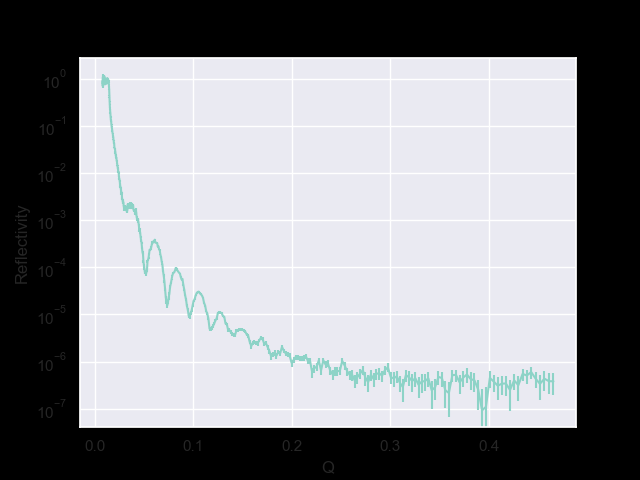

In [17]:
data.plot()
plt.semilogy()
plt.xlabel('Q')
plt.ylabel('Reflectivity')

In [24]:
# Slab structure
from refnx.reflect import SLD, Slab, Structure

# Make the SLD objects for the materials
si = SLD(2.07, name='Si')
sio2 = SLD(3.47, name='SiO2')
film = SLD(2.0, name='Film')
d2o = SLD(6.36, name='D2O')

sio2_layer = sio2(30, 3)
film_layer = film(250, 3)
d2o_layer = d2o(0, 3)

sio2_layer.thick.setp(bounds = (15, 50), vary=True)
sio2_layer.rough.setp(bounds = (0, 10), vary=True)

film_layer.thick.setp(bounds = (200, 300), vary=True)
film_layer.sld.real.setp(bounds = (0.1, 3), vary=True)
film_layer.sld.imag.setp(bounds = (0.1, 3), vary=True)
film_layer.rough.setp(bounds = (0, 10), vary=True)

d2o_layer.thick.setp(bounds = (0, 10), vary=True)
d2o_layer.rough.setp(bounds = (0, 10), vary=True)

structure = si | sio2_layer | film_layer | d2o_layer 
print(structure)

________________________________________________________________________________
Structure:                
solvent: None
reverse structure: False
contract: 0

________________________________________________________________________________
Parameters:      'Si'      
<Parameter: 'Si - thick'  , value=0 (fixed)  , bounds=[-inf, inf]>
________________________________________________________________________________
Parameters:      'Si'      
<Parameter:  'Si - sld'   , value=2.07 (fixed)  , bounds=[-inf, inf]>
<Parameter:  'Si - isld'  , value=0 (fixed)  , bounds=[-inf, inf]>
<Parameter: 'Si - rough'  , value=0 (fixed)  , bounds=[-inf, inf]>
<Parameter:'Si - volfrac solvent', value=0 (fixed)  , bounds=[0.0, 1.0]>
________________________________________________________________________________
Parameters:     'SiO2'     
<Parameter:'SiO2 - thick' , value=30          , bounds=[15.0, 50.0]>
________________________________________________________________________________
Parameters:     'Si

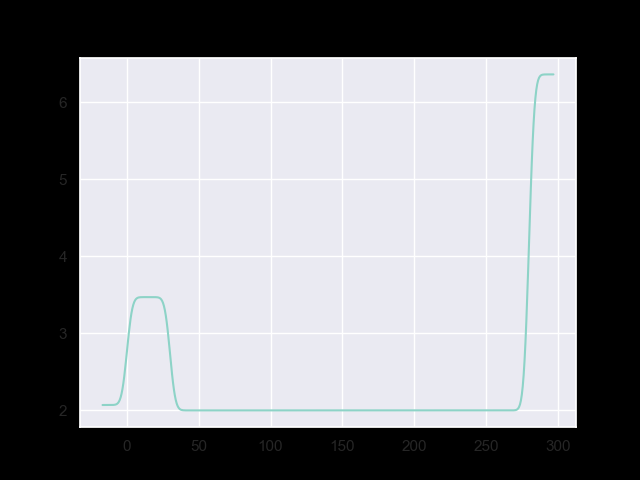

In [27]:
plt.close('all')
plt.plot(*structure.sld_profile())
plt.show()

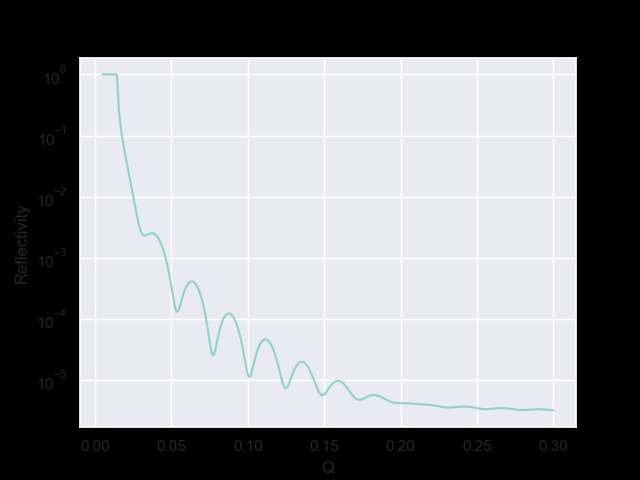

In [32]:
from refnx.reflect import ReflectModel

model = ReflectModel(structure, bkg=3e-6, dq=5.0)
model.scale.setp(bounds=(0.8, 1.2), vary=True)
model.bkg.setp(bounds=(1e-7, 9e-6), vary=True)
model.dq.setp(bounds=(3, 7), vary=True)

plt.close('all')
q = np.linspace(0.005, 0.3, 1001)
plt.plot(q, model(q))
plt.xlabel('Q')
plt.ylabel('Reflectivity')
plt.semilogy()
plt.show()

In [35]:
from refnx.analysis import Objective, Transform, CurveFitter

objective = Objective(model, data, transform = Transform('logY'))

fitter = CurveFitter(objective)
fitter.fit('differential_evolution')

-258.0405884142204: : 63it [00:37,  1.68it/s] 
c:\ProgramData\anaconda3\envs\refl\Lib\site-packages\refnx\analysis\objective.py:770: LinAlgWarning: The following Parameters have no effect on Objective.residuals, please consider fixing them.
[Parameter(value=7.705557931389303, name='D2O - thick', vary=True, bounds=Interval(lb=0.0, ub=10.0), constraint=None)]
  warnings.warn(


 message: Optimization terminated successfully.
 success: True
     fun: -258.0412282242784
       x: [ 9.915e-01  5.032e-07  5.673e+00  3.508e+01  7.510e+00
            2.620e+02  2.545e+00  1.002e-01  8.161e+00  7.706e+00
            4.153e+00]
     nit: 63
    nfev: 10812
     jac: [ 7.601e+01  1.180e+07  0.000e+00 -2.155e+00  3.829e-01
           -1.656e+00 -1.917e+01  5.567e+03  5.392e-01  0.000e+00
           -9.078e-01]
   covar: [[ 4.297e-05  9.412e-12 ...  0.000e+00  6.682e-05]
           [ 9.412e-12  4.806e-16 ...  0.000e+00  1.474e-09]
           ...
           [ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
           [ 6.682e-05  1.474e-09 ...  0.000e+00  1.078e-02]]
  stderr: [ 6.556e-03  2.192e-08  1.305e-16  4.474e-01  2.614e-01
            3.047e-01  1.433e-02  4.475e-03  4.157e-01  0.000e+00
            1.038e-01]

In [38]:
fitter.sample(1000, pool = 1)
fitter.reset()

c:\ProgramData\anaconda3\envs\refl\Lib\site-packages\refnx\analysis\objective.py:770: LinAlgWarning: The following Parameters have no effect on Objective.residuals, please consider fixing them.
[Parameter(value=7.705557931389303, name='D2O - thick', vary=True, bounds=Interval(lb=0.0, ub=10.0), constraint=None)]
  warnings.warn(
100%|██████████| 1000/1000 [07:32<00:00,  2.21it/s]


In [39]:
res = fitter.sample(15, nthin=100, pool=1)

100%|██████████| 1500/1500 [44:14<00:00,  1.77s/it]    


(<Figure size 640x480 with 1 Axes>, <Axes: >)

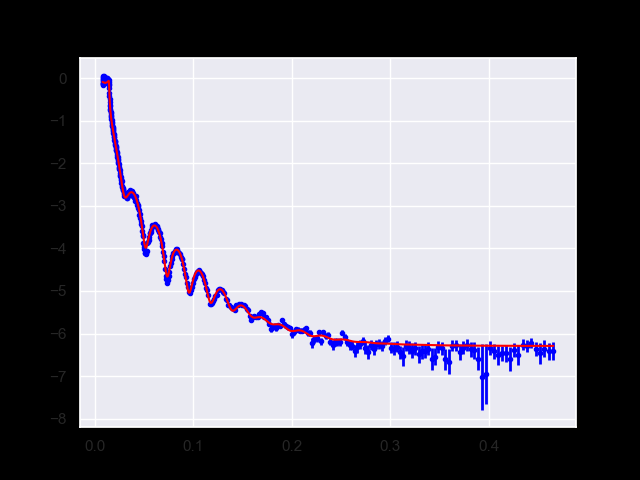

In [40]:
plt.close('all')
objective.plot()


In [43]:
objective.corner()

ModuleNotFoundError: No module named 'corner'